In [2]:
import math
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

Task 1

Proportion of women whose cancer eventually reappears locally: 0.573


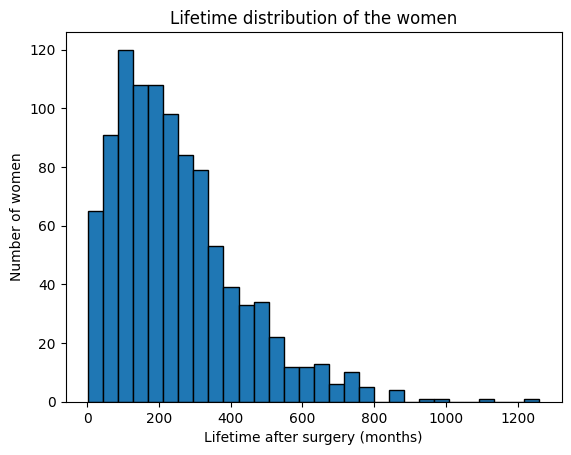

In [3]:
rng = np.random.default_rng(30)

n = 1000        # number of women
t = 120         # 10 years
P = np.array([[0.9915, 0.005, 0.0025, 0,     0.001], 
              [0,      0.986, 0.005,  0.004, 0.005],
              [0,      0,     0.992,  0.003, 0.005],
              [0,      0,     0,      0.991, 0.009],
              [0,      0,     0,      0,     1    ]])

death = 4                                   # death stage (python indexing)
reappear =  1                               # reappearance state (python indexing)
lifetimes = np.zeros(n)                     # lifetime in mounth for each woman
has_reappeared = np.zeros(n)                # did the cancer reappear locally, for each woman


for i in range(n):

    state = 0                               # start at first stage (python indexing)
    t = 0                                   # start at mounth zero

    while state != death:                   # follow until death
        state = rng.choice(5, p=P[state])   # new state
        if state == reappear:               # did reappear?
            has_reappeared[i] = 1
        t += 1                              # add 1 mounth
    
    lifetimes[i] = t

proportion_reappear = sum(has_reappeared) / n
print('Proportion of women whose cancer eventually reappears locally:', proportion_reappear)

plt.hist(lifetimes, bins=30, edgecolor='black')
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Lifetime distribution of the women")
plt.show()

Task 2

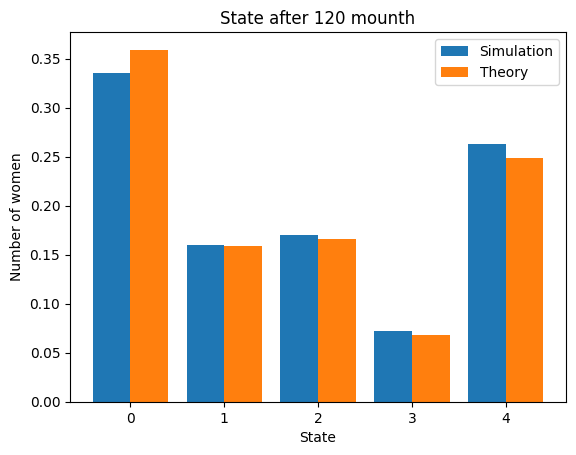

Chi-squared test
Statistic = 2.85844021174111
p-value = 0.5817876012778014


In [4]:
rng = np.random.default_rng(30)

T = 120
states = np.zeros(n)

for i in range(n):
    state = 0                               # start at first stage (python indexing)
    for _ in range(T):                      # follow until T mounth
        state = rng.choice(5, p=P[state])   # new state
    states[i] = state

def pt(p0, P, T):
    return p0 @ np.linalg.matrix_power(P, T)

p0 = np.array([1, 0, 0, 0, 0])
states_theory = pt(p0, P, T)

simulation_counts = np.bincount(states.astype(int), minlength=5)
x = np.arange(5)
plt.bar(x - 0.2, simulation_counts / n, width=0.4, label="Simulation")
plt.bar(x + 0.2, states_theory, width=0.4, label="Theory")
plt.xlabel("State")
plt.ylabel("Number of women")
plt.title("State after 120 mounth")
plt.legend()
plt.show()

# Chi-squared test
statistic, p_value = ss.chisquare(simulation_counts, 1000*states_theory)
print('Chi-squared test')
print('Statistic =', statistic)
print('p-value =', p_value)

Task 3

Theoretical mean lifetime = 262.37161531279304
Simulated mean lifetime   = 251.681


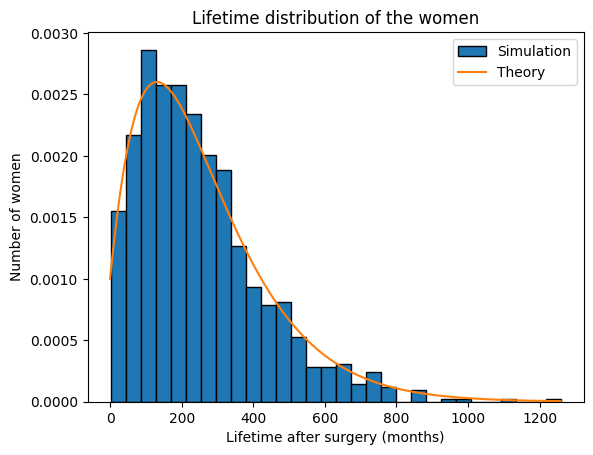

In [5]:
T = 120

pi = np.array([1, 0, 0, 0])     # start with all women a state 1, and no death state
Ps = P[:4, :4]                  # Ps is a 4 × 4 sub-matrix of P formed by removing the last row and column
ps = P[:4, 4]                   # ps is column vector indicating the probability of dying from states 1, 2, 3, 4

def P_T(t):
    return pi @ np.linalg.matrix_power(Ps, t) @ ps

# Theoretical mean lifetime
E_T = pi @ np.linalg.inv(np.eye(4) - Ps) @ np.ones(4)
print("Theoretical mean lifetime =", E_T)
print("Simulated mean lifetime   =", lifetimes.mean())

lifetimes_theory = np.array([P_T(t) for t in range(int(np.max(lifetimes)))])

plt.hist(lifetimes, bins=30, density=True, edgecolor='black', label="Simulation")
plt.plot(np.arange(len(lifetimes_theory)), lifetimes_theory, label="Theory" )
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Number of women")
plt.title("Lifetime distribution of the women")
plt.legend()
plt.show()

Task 4

In [ ]:
rng = np.random.default_rng(30)

T = 12
death = 4                                   # death stage (python indexing)
reappear =  [1, 2, 3]                       # all kinds of reappearance states (python indexing)

valid = 0
lifetimes = np.zeros(1000)

while valid < 1000:

    state = 0                               # start at first stage (python indexing)
    t = 0                                   # start at mounth zero
    has_reappeared = 0
    died = 0

    # find the women who survived the first 12 months following surgery,
    # but whose breast cancer has also reappeared within the first 12 months
    for t in range(T):
        state = rng.choice(5, p=P[state])   # new state
        if state in reappear:               # did reappear?
            has_reappeared = 1
        if state == death:                  # did die?
            died = 1    

    if (has_reappeared == 0) or (died == 1):
        continue

    # continue until death
    t = 12
    while state != death:                   # follow until death
        state = rng.choice(5, p=P[state])   # new state
        if state == death:                  # did die?
            break
        t += 1
    
    valid += 1
    lifetimes[valid-1] = t

print('Expected lifetime =', np.mean(lifetimes))

Expected lifetime = 169.037


Task 5

In [17]:
rng = np.random.default_rng(30)

n = 200
m = 100
fractions = np.zeros(m)

for i in range(m):            # do this 100 times
    lifetimes = np.zeros(n)

    for j in range(n):
        t = 0
        state = 0

        while state != death:
            state = rng.choice(5, p=P[state])   # new state
            if state == death:                  # did die?
                lifetimes[j] = t
                break
            t += 1

    fractions[i] = np.sum(lifetimes <= 350) / n

print('The mean is:', np.mean(fractions))
print('The variance is:', np.var(fractions, ddof=1))

(np.float64(0.74025), np.float64(0.0010729166666666678))

In [21]:
rng = np.random.default_rng(30)

n = 200
m = 100

X = np.zeros(m)
Z = np.zeros(m)

for i in range(m):            # do this 100 times
    lifetimes = np.zeros(n)

    for j in range(n):
        t = 0
        state = 0

        while state != death:
            state = rng.choice(5, p=P[state])   # new state
            if state == death:                  # did die?
                lifetimes[j] = t
                break
            t += 1

    Z[i] = np.mean(lifetimes) 
    X[i] = np.sum(lifetimes <= 350) / n

life_theory = lifetimes_theory.flatten()

c = - (np.cov(X, Z)[0,1]) / (np.var(Z, ddof=1))
Y = X + c * (Z - E_T)
print('The mean is:', np.mean(Y))
print('The variance is:', np.var(Y, ddof=1))

The mean is: 0.7381255067153397
The variance is: 0.00035138865266074506
